## Temp conversion sequential workflow
### Celcius to Fahrenheit

In [1]:
from langgraph.graph import StateGraph,START,END
from pydantic import Field,BaseModel

In [2]:
class Tempstate(BaseModel):
    temp_cel:float = Field(description="Enter the temperature in celcius")
    temp_fah:float = Field(default=0.0,description="Temperature in Fahrenheit is")

In [3]:
def convert_temp(state:Tempstate)->Tempstate:
    temp=state.temp_cel
    ans=((9*temp)/5)+32
    state.temp_fah=round(ans,2)
    return state

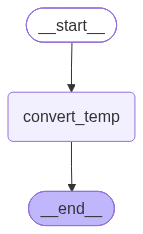

In [4]:
graph=StateGraph(Tempstate)
graph.add_node("convert_temp",convert_temp)

graph.add_edge(START,"convert_temp")
graph.add_edge("convert_temp",END)

graph=graph.compile()
graph

In [5]:
response = graph.invoke({'temp_cel': 28.5})
print(response)

{'temp_cel': 28.5, 'temp_fah': 83.3}


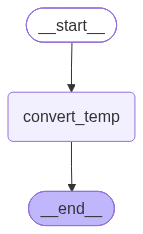

In [6]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## Adding weather Status Node

In [7]:
from typing import TypedDict

In [17]:
class WeatherStatus(TypedDict):
    temp_cel:float
    temp_far:float
    weather_stat:str

In [22]:
def convert_temp(state:WeatherStatus)->WeatherStatus:
    temp=state["temp_cel"]
    ans=((9*temp)/5)+32
    state["temp_far"]=round(ans,2)
    return state

In [23]:
def weather_status(state:WeatherStatus)->WeatherStatus:
    temp=state["temp_far"]
    if temp>=86:
        state["weather_stat"]="Hot"
    elif temp>=68:
        state["weather_stat"]="Warm"
    else:
        state["weather_stat"]="COld"

    return state

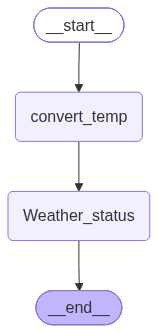

In [24]:
graph=StateGraph(WeatherStatus)
graph.add_node("convert_temp",convert_temp)
graph.add_node("Weather_status",weather_status)


graph.add_edge(START,"convert_temp")
graph.add_edge("convert_temp","Weather_status")
graph.add_edge("Weather_status",END)

workflow=graph.compile()
workflow

In [27]:
response=workflow.invoke({"temp_cel":30.8})
print(response)

{'temp_cel': 30.8, 'temp_far': 87.44, 'weather_stat': 'Hot'}


## LLM Model call using langgraph

In [29]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

True

In [30]:
model=init_chat_model(
    "openai/gpt-oss-120b",
    model_provider="groq",
    temperature=0.5
)

In [31]:
class QAState(TypedDict):
    ques:str
    ans:str

In [37]:
def question_ans(state:QAState)->QAState:
    prompt=state["ques"]
    response=model.invoke(prompt)
    state["ans"]=response.content
    return state

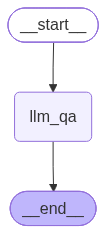

In [38]:
graph=StateGraph(QAState)

graph.add_node("llm_qa",question_ans)

graph.add_edge(START,"llm_qa")
graph.add_edge("llm_qa",END)

work=graph.compile()
work

In [39]:
response=work.invoke({"ques":"Tell me the difference between ai agents and agentic ai"})
response["ans"]

'## TL;DR  \n\n| Term | What it usually means | Typical scope | Key technical traits | Typical concerns |\n|------|-----------------------|--------------|----------------------|------------------|\n| **AI\u202fagent** | A software entity that **perceives** an environment, **acts** on it, and **optimises** a (usually pre‑specified) objective. | Narrow to moderate‑breadth (games, robotics, dialogue systems, recommendation engines, etc.) | • Defined observation‑action loop  <br>• Goal or reward function supplied by the designer  <br>• Often built with reinforcement learning, planning, or rule‑based policies  <br>• May be single‑shot or multi‑step, but the *policy* is static unless explicitly updated | • Does what it was programmed to do (or learns to do it) – no “own” agenda. <br>• Safety is about the reward function, exploration, and robustness. |\n| **Agentic\u202fAI** | An AI system that **exhibits agency** – i.e., the capacity to *form* its own sub‑goals, *plan* over long horizons, *s

## Prompt Chaining example
### Blog Generator

In [48]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str

In [49]:
def generate_outline(state:BlogState)->BlogState:
    title1=state["title"]
    prompt=f"Generate a detailed outline for the following title {title1}"
    response=model.invoke(prompt).content
    state["outline"]=response
    return state

def generate_blog(state:BlogState)->BlogState:
    title=state["title"]
    outline=state["outline"]
    prompt=f"Generate a blog based on the title {title} using the following outline{outline}"
    response=model.invoke(prompt).content
    state["content"]=response
    return state

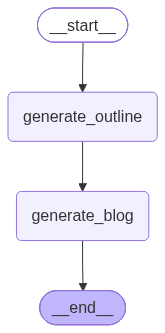

In [50]:
graph=StateGraph(BlogState)

graph.add_node("generate_outline",generate_outline)
graph.add_node("generate_blog",generate_blog)

graph.add_edge(START,"generate_outline")
graph.add_edge("generate_outline","generate_blog")
graph.add_edge("generate_blog",END)

work=graph.compile()
work

In [51]:
initial_state={"title":"Importance of Artificial Intelligence in Todays era"}
final_state=work.invoke(initial_state)
print(final_state)

{'title': 'Importance of Artificial Intelligence in Todays era', 'outline': '**Title:** *The Importance of Artificial Intelligence in Today’s Era*  \n\n---\n\n### I. Introduction  \n1. **Hook / Opening Statement** – Brief anecdote or statistic that illustrates AI’s pervasiveness (e.g., “One in three smartphones now runs an AI‑powered assistant”).  \n2. **Definition of Artificial Intelligence** – Concise explanation of AI, machine learning, deep learning, and related terms.  \n3. **Historical Snapshot** – From early symbolic AI to modern neural networks; why the current moment is a “breakthrough era.”  \n4. **Thesis Statement** – Articulate the central claim: AI is reshaping economies, societies, and individual lives, making its understanding and responsible deployment crucial for the 21st‑century world.  \n\n---\n\n### II. Economic Impact  \n| A. Productivity & Growth | B. Industry Transformation | C. Labor Market Dynamics |\n|---|---|---|\n| 1. Automation of repetitive tasks → cost re

In [52]:
print(final_state["outline"])

**Title:** *The Importance of Artificial Intelligence in Today’s Era*  

---

### I. Introduction  
1. **Hook / Opening Statement** – Brief anecdote or statistic that illustrates AI’s pervasiveness (e.g., “One in three smartphones now runs an AI‑powered assistant”).  
2. **Definition of Artificial Intelligence** – Concise explanation of AI, machine learning, deep learning, and related terms.  
3. **Historical Snapshot** – From early symbolic AI to modern neural networks; why the current moment is a “breakthrough era.”  
4. **Thesis Statement** – Articulate the central claim: AI is reshaping economies, societies, and individual lives, making its understanding and responsible deployment crucial for the 21st‑century world.  

---

### II. Economic Impact  
| A. Productivity & Growth | B. Industry Transformation | C. Labor Market Dynamics |
|---|---|---|
| 1. Automation of repetitive tasks → cost reduction. | 1. Manufacturing: predictive maintenance, smart factories. | 1. Job displacement 

In [53]:
print(final_state["content"])

# **The Importance of Artificial Intelligence in Today’s Era**

*By [Your Name] – [Date]*  

---

## I. Introduction  

### 1. Hook – AI Is Already in Your Pocket  

Imagine opening your phone and asking, “What’s the traffic like to work?” In less than a second, a voice‑assistant pulls data from satellite imagery, historic congestion patterns, and real‑time sensor feeds to give you a route. According to a 2024 Counterpoint report, **one in three smartphones now runs an AI‑powered assistant**, and that number is climbing fast.  

### 2. What Exactly Is Artificial Intelligence?  

Artificial Intelligence (AI) is the umbrella term for computer systems that can **perceive, reason, learn, and act** in ways that, until recently, were thought to require human intelligence. Within AI, three sub‑fields dominate the conversation today:

| Term | Quick Definition |
|------|-------------------|
| **Machine Learning (ML)** | Algorithms that improve automatically through experience (i.e., data). |
|